# Project 2: Exploratory Data Analysis (EDA) Report  
---
## Assigned Topic:  
__Wind Turbines__

## Selected Problem Statement:  
Our client, a renewable energy private equity firm, is looking to acquire U.S. wind farms. However, before investing, they need to know what a historically successful wind farm looks like. We are tasked with analyzing turbine specifications, geographic locations, and historical energy metrics across different regions. By identifying which turbine models and locations consistently yield the highest capacity, we can help the investment committee target assets with a proven track record.

## 1. Introduction & Objectives  

### 1.1 Context & Background  
Wind energy is growing incredibly fast in the U.S. As of 2021, there are over 70,000 wind turbines across the country. A private equity firm hired us to figure out which U.S. wind farms are actually worth acquiring. Buying just any farm isn't a great strategy—we need to dig into historical data to understand exactly what makes a wind farm successful, from the turbine tech itself to the geographic location and local wind speeds.

### 1.2 Core Analytical Objectives  

 * Find out which states and regions have the highest concentration of wind turbines.
 * Look at how turbine technology (height, rotor width, and power capacity) has changed over the years.
 * Identify the top manufacturers that dominate the market.
 * See how the physical size of a turbine changes how much power it produces.
 * Combine the turbine data with external wind speeds and electricity costs to find the "sweet spot" for investment.

## 2. Environment Setup & Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline


In [2]:
# Load data using strictly relative file paths
turbines = pd.read_csv('../Data/wind-turbines.csv', encoding='ISO-8859-1', low_memory=False)

wind_speeds = pd.read_csv('../Data/extra/windiest-states-in-the-us.-2025.csv')
elec_rates = pd.read_csv('../Data/extra/average_electricity_rates.csv')
elec_bills = pd.read_csv('../Data/extra/average_electricity_bills.csv')

print(f'Turbines dataset: {turbines.shape[0]:,} rows x {turbines.shape[1]} columns')
print(f'Wind speeds dataset: {wind_speeds.shape[0]} rows')
print(f'Electricity rates dataset: {elec_rates.shape[0]} rows')
print(f'Electricity bills dataset: {elec_bills.shape[0]} rows')

Turbines dataset: 70,808 rows x 27 columns
Wind speeds dataset: 50 rows
Electricity rates dataset: 51 rows
Electricity bills dataset: 50 rows


In [3]:
# Load EIA-923 Net Generation (MWh) data for wind plants
# Source: EIA-923 Monthly Generation and Fuel Consumption Time Series File, 2025 Early Release
eia_file = '../Data/EIA923_Schedules_2_3_4_5_M_12_2025_Early_Release_30JUN2026.xlsx'

# Read only the columns we need (Col 1 = Plant Id, Col 14 = Prime Mover, Col 96 = Net Generation annual total)
# The 2025 ER file has a warning column at position 0, shifting data columns right by 1
eia_raw = pd.read_excel(eia_file, sheet_name='Page 1 Generation and Fuel Data',
                        header=None, skiprows=7, usecols=[1, 14, 96],
                        names=['Plant_Id', 'Prime_Mover', 'Net_Gen_Annual_MWh'])

# Keep only wind generators
eia_wind = eia_raw[eia_raw['Prime_Mover'].isin(['WT', 'WS'])].copy()
eia_wind['Plant_Id'] = eia_wind['Plant_Id'].astype(int)

# Drop rows with missing generation (some early-release entries may be incomplete)
eia_wind = eia_wind.dropna(subset=['Net_Gen_Annual_MWh'])

# Aggregate to plant level (one plant may have multiple wind generators)
plant_gen = eia_wind.groupby('Plant_Id')['Net_Gen_Annual_MWh'].sum().reset_index()
plant_gen.rename(columns={'Net_Gen_Annual_MWh': 'Net_Generation_MWh'}, inplace=True)

print(f'EIA-923 wind plants with generation data: {len(plant_gen)}')
print(f'Total net generation (full year 2025): {plant_gen["Net_Generation_MWh"].sum():,.0f} MWh')
print()

# Merge net generation into the turbines dataframe via eia_id -> Plant_Id
turbines['eia_id_int'] = pd.to_numeric(turbines['eia_id'], errors='coerce').astype('Int64')

# Count turbines per plant so we can split plant-level generation across turbines
turbine_count_per_plant = turbines.groupby('eia_id_int').size().reset_index(name='Turbines_at_Plant')

# Merge plant generation then normalize by turbine count
turbines = turbines.merge(plant_gen, how='left', left_on='eia_id_int', right_on='Plant_Id')
turbines = turbines.merge(turbine_count_per_plant, how='left', on='eia_id_int')

# Divide plant-level generation by number of turbines at that plant
turbines['Net_Generation_MWh'] = turbines['Net_Generation_MWh'] / turbines['Turbines_at_Plant']

# Calculate annual capacity factor: NetGen_MWh / (t_cap_kW * 8760 hours / 1000)
annual_hours = 8760
turbines['Capacity_Factor'] = (turbines['Net_Generation_MWh'] /
                                (turbines['t_cap'] * annual_hours / 1000))

# Clip to realistic range (0 to 1)
turbines['Capacity_Factor'] = turbines['Capacity_Factor'].clip(0, 1)

matched = turbines['Net_Generation_MWh'].notna().sum()
print(f'Turbines matched with generation data: {matched:,} ({matched/len(turbines)*100:.1f}%)')
print(f'Mean annual capacity factor: {turbines["Capacity_Factor"].mean():.3f} ({turbines["Capacity_Factor"].mean()*100:.1f}%)')
print()

# Cleanup
turbines.drop(columns=['eia_id_int', 'Turbines_at_Plant'], inplace=True)

EIA-923 wind plants with generation data: 1318
Total net generation (full year 2025): 461,679,643 MWh

Turbines matched with generation data: 62,888 (88.8%)
Mean annual capacity factor: 0.327 (32.7%)



---
## 3. Data Handling

In [4]:
# Initial assessment: shapes, nulls, and types
print('Turbines DataFrame Info:')
print(turbines.info())
print()
print('First 3 rows:')
display(turbines.head(3))

Turbines DataFrame Info:


<class 'pandas.DataFrame'>
RangeIndex: 70808 entries, 0 to 70807
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   case_id             70808 non-null  int64  
 1   faa_ors             65016 non-null  str    
 2   faa_asn             65686 non-null  str    
 3   usgs_pr_id          38263 non-null  float64
 4   eia_id              65015 non-null  float64
 5   t_state             70808 non-null  str    
 6   t_county            70808 non-null  str    
 7   t_fips              70808 non-null  int64  
 8   p_name              70808 non-null  str    
 9   p_year              70195 non-null  float64
 10  p_tnum              70808 non-null  int64  
 11  p_cap               66326 non-null  float64
 12  t_manu              65168 non-null  str    
 13  t_model             65031 non-null  str    
 14  t_cap               65328 non-null  float64
 15  t_hh                64628 non-null  float64
 16  t_rd           

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat,Plant_Id,Net_Generation_MWh,Capacity_Factor
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908,NaN,NaN,NaN
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435,NaN,NaN,NaN
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644,NaN,NaN,NaN


In [5]:
# Null analysis
null_pct = (turbines.isnull().sum() / len(turbines) * 100).sort_values(ascending=False)
null_df = pd.DataFrame({'Null Count': turbines.isnull().sum(), 'Null %': null_pct})
null_df = null_df[null_df['Null Count'] > 0]
display(null_df)

,Null Count,Null %
Capacity_Factor,8459,11.946390
Net_Generation_MWh,7920,11.185177
Plant_Id,7920,11.185177
eia_id,5793,8.181279
faa_asn,5122,7.233646
faa_ors,5792,8.179867
p_cap,4482,6.329793
p_year,613,0.865721
retrofit_year,64822,91.546153
t_cap,5480,7.739239


In [6]:
# Data cleaning: parse dates, fix dtypes
turbines['p_year'] = turbines['p_year'].astype('Int64')
turbines['t_img_date'] = pd.to_datetime(turbines['t_img_date'], errors='coerce')

# Clean up county names (strip whitespace)
turbines['t_county'] = turbines['t_county'].str.strip()

# Add Census Region mapping
state_to_region = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest',
    'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest',
    'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South',
    'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South',
    'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West'
}
turbines['census_region'] = turbines['t_state'].map(state_to_region)

# Add decade for grouping
turbines['decade'] = (turbines['p_year'] // 10) * 10

print('Data cleaning complete.')
print(f'Census regions: {turbines["census_region"].value_counts().to_dict()}')

Data cleaning complete.
Census regions: {'Midwest': 26716, 'South': 22962, 'West': 18416, 'Northeast': 2650}


---
## 4. Exploratory Data Analysis (EDA)

### 4.1. Summary Statistics & Distribution Overview

In [7]:
# Descriptive stats for key numeric columns
key_cols = ['p_year', 'p_cap', 't_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh']
display(turbines[key_cols].describe().round(2))

,p_year,p_cap,t_cap,t_hh,t_rd,t_rsa,t_ttlh
count,70195.0,66326.00,65328.00,64628.00,64874.00,64874.00,64628.00
mean,2011.65,170.18,1963.53,81.05,95.66,7618.50,129.05
std,7.88,104.48,717.07,12.03,23.42,3309.23,22.19
min,1981.0,0.05,50.00,19.00,13.40,141.03,30.40
25%,2008.0,99.00,1500.00,80.00,82.00,5281.02,121.00
50%,2012.0,158.00,2000.00,80.00,100.00,7853.98,130.10
75%,2018.0,211.22,2300.00,87.00,110.00,9503.32,145.10
max,2021.0,525.02,6000.00,131.00,155.00,18869.19,199.60


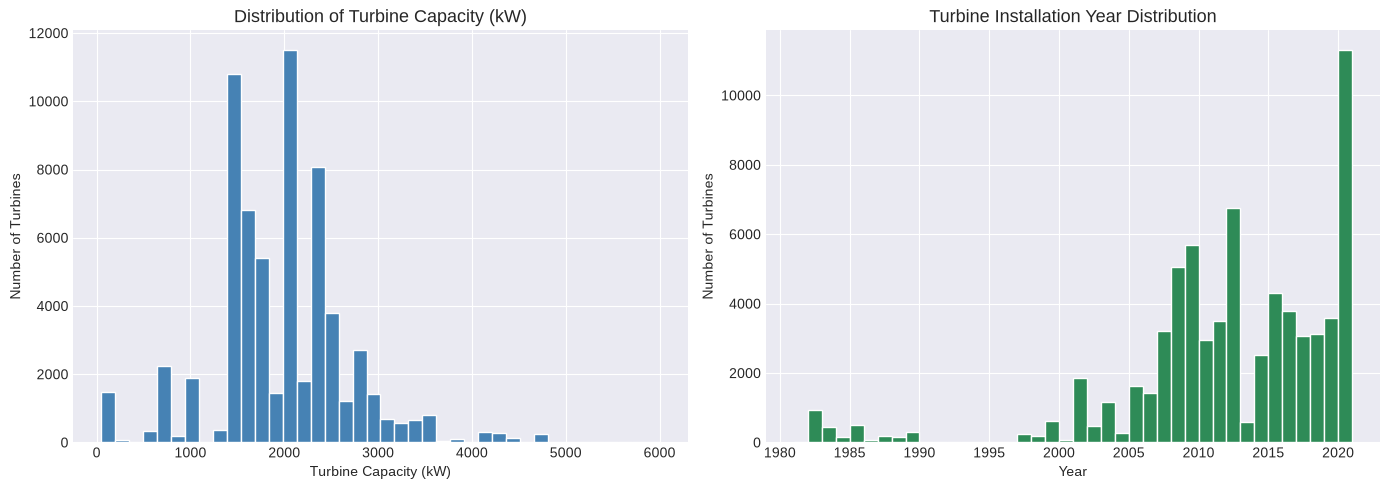

In [8]:
# Distribution of turbine capacity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(turbines['t_cap'].dropna(), bins=40, edgecolor='white', color='steelblue')
axes[0].set_title('Distribution of Turbine Capacity (kW)', fontsize=13)
axes[0].set_xlabel('Turbine Capacity (kW)')
axes[0].set_ylabel('Number of Turbines')

axes[1].hist(turbines['p_year'].dropna(), bins=40, edgecolor='white', color='seagreen')
axes[1].set_title('Turbine Installation Year Distribution', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Turbines')

plt.tight_layout()
plt.show()

**Visualization 1 Interpretation:**  
 Looking at the distribution, the vast majority of turbines produce around 1.5 to 2.3 MW of power. But if you look to the right of the chart, you can see a trend of massive, newer turbines pushing up to 6 MW. We also see a huge spike in new installations starting around 2005 and peaking in 2020, which is likely tied to federal green energy tax credits driving up construction.

### 4.2. Geographic & Regional Analysis

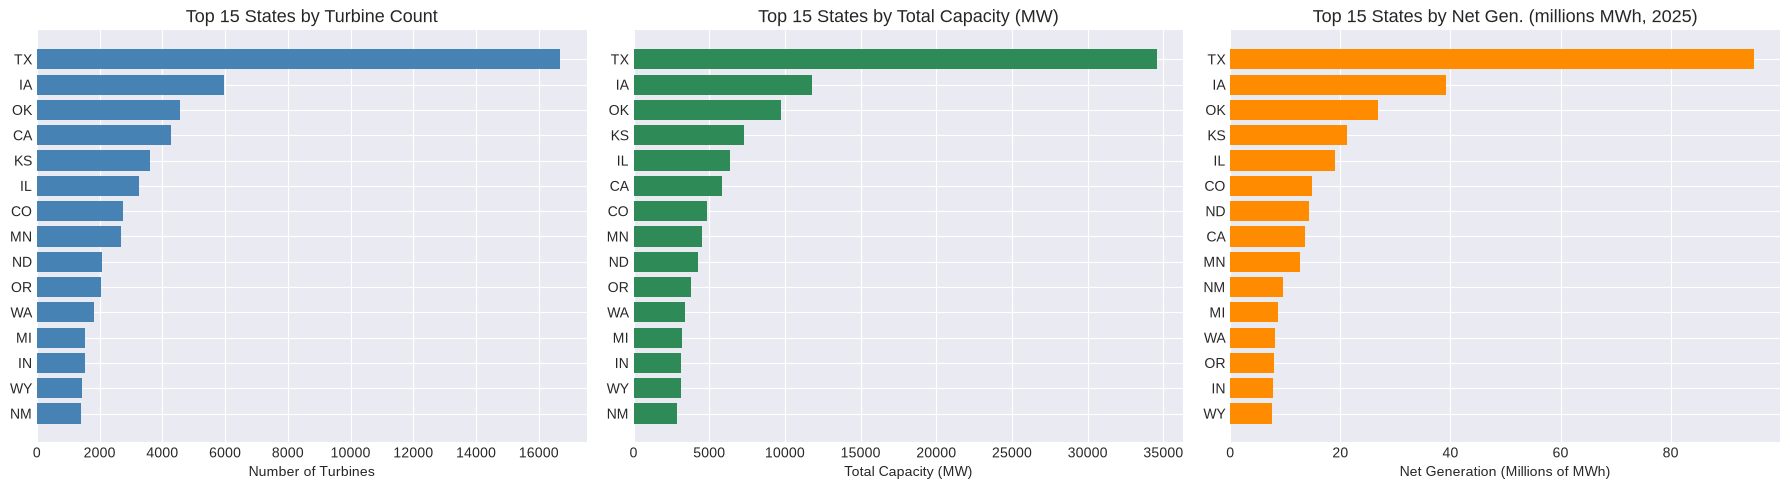

,t_state,Turbine_Count,sum,Avg_Capacity_kW,Total_Capacity_MW,Net_Generation_MWh
38,TX,16688,34586804.0,2072.555369,34586.804,9.510929e+07
10,IA,5968,11780452.0,1973.936327,11780.452,3.927671e+07
31,OK,4556,9767565.0,2143.890474,9767.565,2.679389e+07
3,CA,4286,5830496.0,1360.358376,5830.496,1.352340e+07
14,KS,3622,7318840.0,2020.662617,7318.840,2.126652e+07
12,IL,3248,6373758.0,1962.363916,6373.758,1.910699e+07
4,CO,2736,4875290.0,1781.904240,4875.290,1.481417e+07
19,MN,2674,4537105.0,1696.748317,4537.105,1.259026e+07
23,ND,2092,4268080.0,2040.191205,4268.080,1.423684e+07
32,OR,2058,3764760.0,1829.329446,3764.760,7.983760e+06


In [9]:
# Top 15 states by turbine count and total capacity
# 1. First, just get the basic sum, count, and mean
state_counts = turbines.groupby('t_state')['t_cap'].agg(['count', 'sum', 'mean']).reset_index()

# 2. Rename the columns so they make sense
state_counts.rename(columns={'count': 'Turbine_Count', 'mean': 'Avg_Capacity_kW'}, inplace=True)

# 3. Create the MW column using simple division
state_counts['Total_Capacity_MW'] = state_counts['sum'] / 1000

# 4. Add actual net generation from EIA-923 (aggregated per state)
state_gen = turbines.groupby('t_state')['Net_Generation_MWh'].sum().reset_index()
state_counts = state_counts.merge(state_gen, on='t_state', how='left')

# 5. Sort and get the top 15 by turbine count
state_counts = state_counts.sort_values(by='Turbine_Count', ascending=False).head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sort ascending so the biggest state is at the bottom of the bar chart
plot_data = state_counts.sort_values(by='Turbine_Count', ascending=True)
axes[0].barh(plot_data['t_state'], plot_data['Turbine_Count'], color='steelblue')
axes[0].set_title('Top 15 States by Turbine Count', fontsize=13)
axes[0].set_xlabel('Number of Turbines')

# Sort ascending for capacity chart too
plot_data_cap = state_counts.sort_values(by='Total_Capacity_MW', ascending=True)
axes[1].barh(plot_data_cap['t_state'], plot_data_cap['Total_Capacity_MW'], color='seagreen')
axes[1].set_title('Top 15 States by Total Capacity (MW)', fontsize=13)
axes[1].set_xlabel('Total Capacity (MW)')

# Sort ascending for net generation chart
plot_data_gen = state_counts.sort_values(by='Net_Generation_MWh', ascending=True)
axes[2].barh(plot_data_gen['t_state'], plot_data_gen['Net_Generation_MWh'] / 1_000_000, color='darkorange')
axes[2].set_title('Top 15 States by Net Gen. (millions MWh, 2025)', fontsize=13)
axes[2].set_xlabel('Net Generation (Millions of MWh)')

plt.tight_layout()
plt.show()

display(state_counts)

In [10]:
# Census Region breakdown
region_stats = turbines.groupby('census_region').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_kW=('t_cap', 'sum'),
    Net_Generation_MWh=('Net_Generation_MWh', 'sum'),
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Hub_Height_m=('t_hh', 'mean'),
    Avg_Rotor_Diameter_m=('t_rd', 'mean')
).round(2)

region_stats['Total_Capacity_MW'] = region_stats['Total_Capacity_kW'] / 1000
region_stats['Share_of_Total_%'] = (region_stats['Turbine_Count'] / region_stats['Turbine_Count'].sum() * 100).round(1)
display(region_stats.sort_values('Turbine_Count', ascending=False))

,Turbine_Count,Total_Capacity_kW,Net_Generation_MWh,Avg_Capacity_kW,Avg_Hub_Height_m,Avg_Rotor_Diameter_m,Total_Capacity_MW,Share_of_Total_%
census_region,,,,,,,,
Midwest,25106,50108499.0,1.523739e+08,1995.88,84.09,98.61,50108.499,38.5
South,21846,45538499.0,1.247085e+08,2084.52,82.23,100.34,45538.499,33.5
West,15711,27390061.0,6.946842e+07,1743.37,73.98,85.46,27390.061,24.1
Northeast,2602,5110500.0,1.155604e+07,1964.07,83.06,87.94,5110.500,4.0


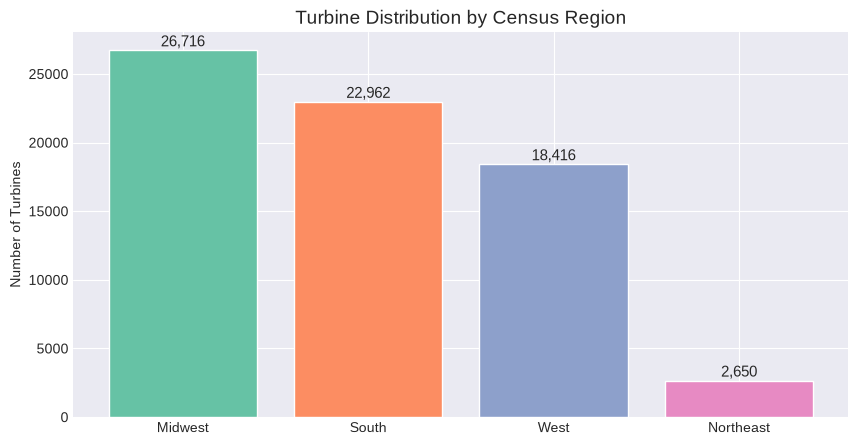

In [11]:
# Regional turbine count bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
region_counts = turbines['census_region'].value_counts()
bars = ax.bar(region_counts.index, region_counts.values, color=colors, edgecolor='white')
ax.set_title('Turbine Distribution by Census Region', fontsize=14)
ax.set_ylabel('Number of Turbines')

for bar, val in zip(bars, region_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=11)

plt.show()

**Visualization 2 Interpretation:**  

The Midwest absolutely dominates the wind energy space with over 26,000 turbines. This makes total sense given the flat terrain and consistent winds of the Great Plains. Texas alone is crazy—it has over 16,600 turbines, which almost matches the entire Western US combined. 

### 4.3. Turbine Technology Evolution

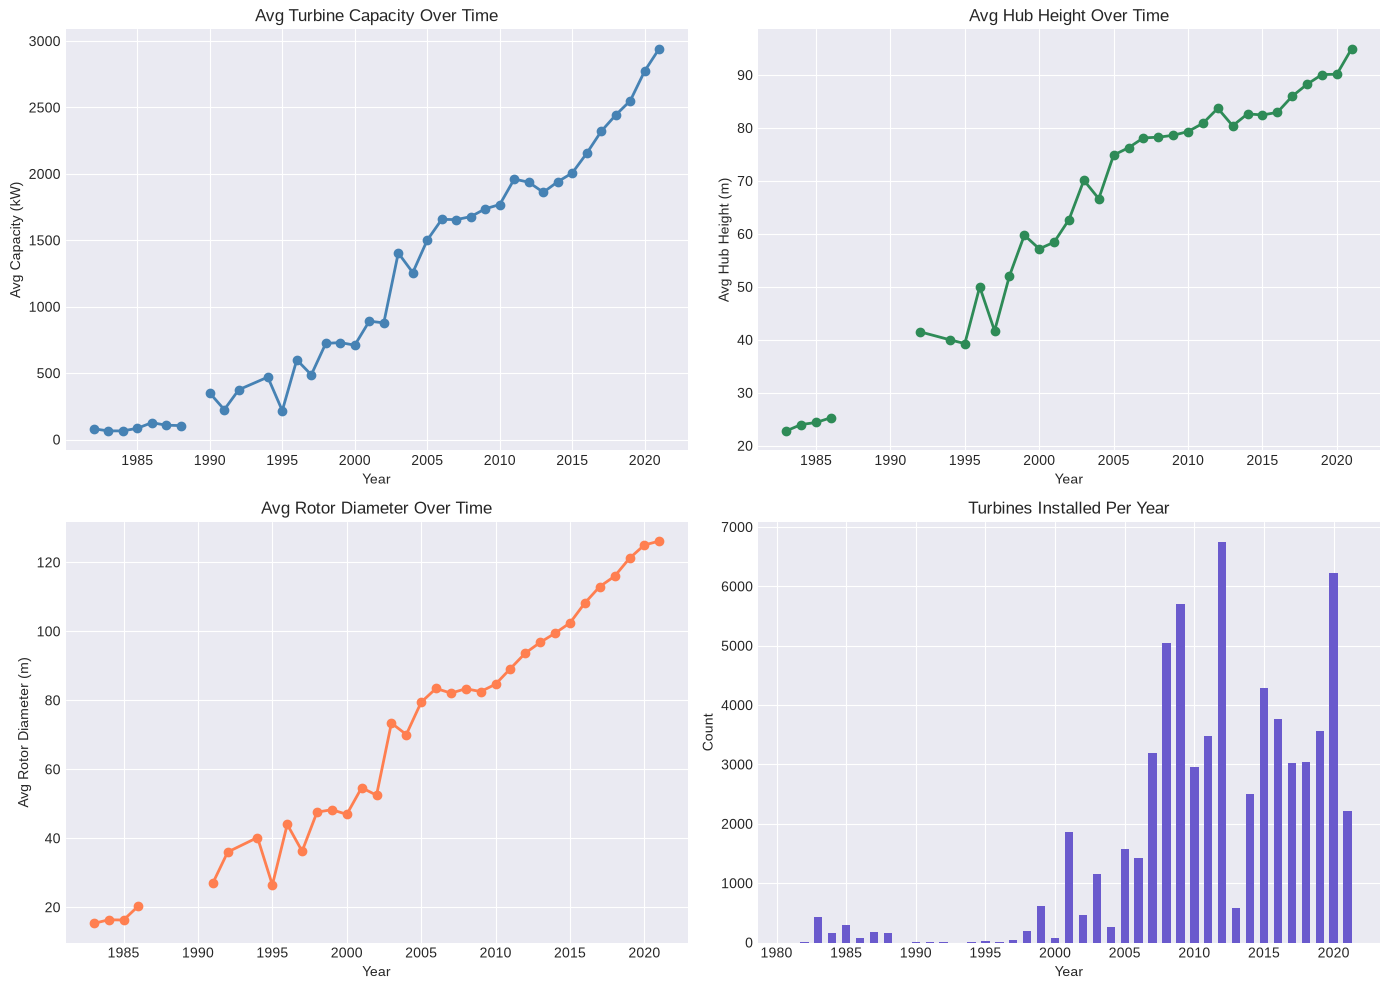

In [12]:
# How turbine specs have changed over time
yearly_specs = turbines.groupby('p_year').agg(
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Hub_Height_m=('t_hh', 'mean'),
    Avg_Rotor_Diameter_m=('t_rd', 'mean'),
    Turbine_Count=('t_cap', 'count')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(yearly_specs['p_year'], yearly_specs['Avg_Capacity_kW'], marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_title('Avg Turbine Capacity Over Time', fontsize=12)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Avg Capacity (kW)')

axes[0, 1].plot(yearly_specs['p_year'], yearly_specs['Avg_Hub_Height_m'], marker='o', linewidth=2, color='seagreen')
axes[0, 1].set_title('Avg Hub Height Over Time', fontsize=12)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Avg Hub Height (m)')

axes[1, 0].plot(yearly_specs['p_year'], yearly_specs['Avg_Rotor_Diameter_m'], marker='o', linewidth=2, color='coral')
axes[1, 0].set_title('Avg Rotor Diameter Over Time', fontsize=12)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Avg Rotor Diameter (m)')

axes[1, 1].bar(yearly_specs['p_year'], yearly_specs['Turbine_Count'], color='slateblue', width=0.6)
axes[1, 1].set_title('Turbines Installed Per Year', fontsize=12)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Visualization 3 Interpretation:**  
This chart really highlights how fast turbine tech has evolved. Back in the 90s, turbines barely pushed 500 kW. Fast forward to 2020, and the average is pushing 3,000 kW (3 MW). To capture that much wind, manufacturers had to build much taller towers (jumping from 50m to over 90m) and significantly wider rotors.

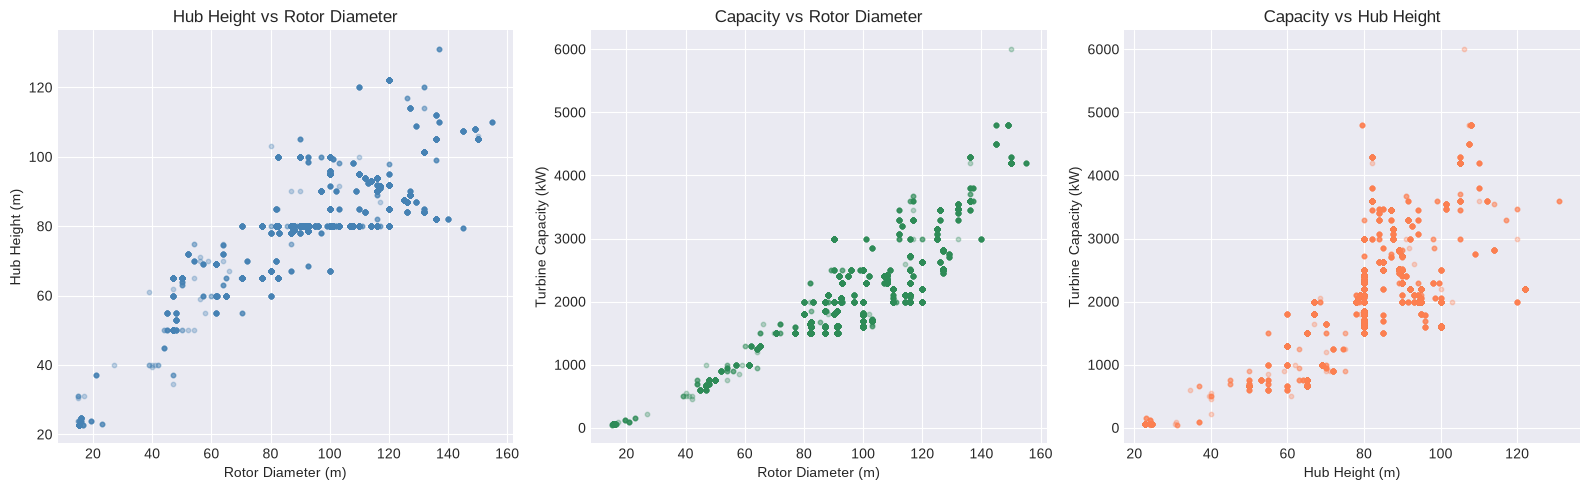

In [13]:
# Relationship between physical specs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sample = turbines.dropna(subset=['t_cap', 't_hh', 't_rd', 't_ttlh']).sample(min(10000, len(turbines)), random_state=42)

axes[0].scatter(sample['t_rd'], sample['t_hh'], alpha=0.3, s=10, c='steelblue')
axes[0].set_xlabel('Rotor Diameter (m)')
axes[0].set_ylabel('Hub Height (m)')
axes[0].set_title('Hub Height vs Rotor Diameter')

axes[1].scatter(sample['t_rd'], sample['t_cap'], alpha=0.3, s=10, c='seagreen')
axes[1].set_xlabel('Rotor Diameter (m)')
axes[1].set_ylabel('Turbine Capacity (kW)')
axes[1].set_title('Capacity vs Rotor Diameter')

axes[2].scatter(sample['t_hh'], sample['t_cap'], alpha=0.3, s=10, c='coral')
axes[2].set_xlabel('Hub Height (m)')
axes[2].set_ylabel('Turbine Capacity (kW)')
axes[2].set_title('Capacity vs Hub Height')

plt.tight_layout()
plt.show()

**Visualization 4 Interpretation:**  
There’s a really obvious relationship here: bigger rotors and taller towers mean more power. Notice how the dots cluster together instead of forming a perfectly smooth line? This tells us that manufacturers build specific model "families" (like standard sizes) rather than custom-building every single turbine.

### 4.4. Manufacturer & Model Analysis

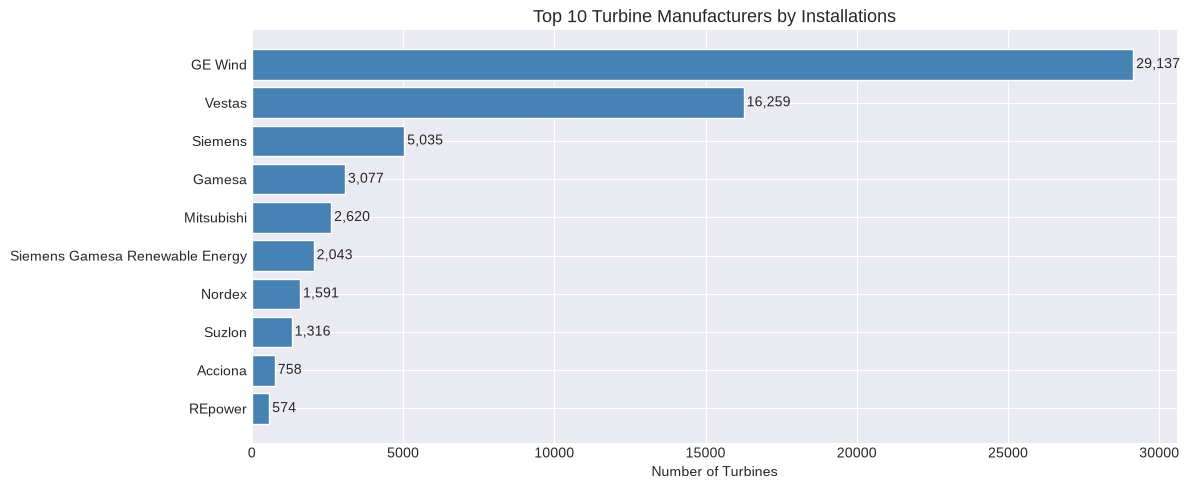

GE Wind dominates with 29,137 turbines (41.1% market share).


In [14]:
# Top manufacturers
top_manus = turbines['t_manu'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_manus.index[::-1], top_manus.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 10 Turbine Manufacturers by Installations', fontsize=13)
ax.set_xlabel('Number of Turbines')

for bar, val in zip(bars, top_manus.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()
print(f'GE Wind dominates with {top_manus.iloc[0]:,} turbines ({top_manus.iloc[0]/len(turbines)*100:.1f}% market share).')

In [15]:
# Manufacturer capacity comparison
manu_stats = turbines.groupby('t_manu').agg(
    Count=('t_cap', 'count'),
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Hub_Height_m=('t_hh', 'mean'),
    Avg_Rotor_Diameter_m=('t_rd', 'mean'),
    Net_Generation_MWh=('Net_Generation_MWh', 'sum')
).round(2)

manu_stats = manu_stats[manu_stats['Count'] >= 100].sort_values('Avg_Capacity_kW', ascending=False)
display(manu_stats.head(15))

,Count,Avg_Capacity_kW,Avg_Hub_Height_m,Avg_Rotor_Diameter_m,Net_Generation_MWh
t_manu,,,,,
Nordex,1591,3195.12,91.03,123.52,1.115221e+07
Siemens Gamesa Renewable Energy,2033,2628.16,84.91,112.37,1.525531e+07
Clipper,285,2500.00,80.21,96.07,1.466724e+06
Siemens,5035,2341.27,80.71,102.66,3.125263e+07
Vestas,16259,2074.50,82.05,99.03,9.760372e+07
REpower,574,2034.06,80.99,92.50,2.636401e+06
Suzlon,1316,2009.16,79.16,86.25,5.056218e+06
GE Wind,29131,1894.33,82.52,97.13,1.661224e+08
Goldwind,195,1884.97,85.18,92.93,9.733095e+05


### 4.5. Regional Tech Profiles (Target Analysis)

In [16]:
# Region vs manufacturer cross-tab
region_manu = pd.crosstab(turbines['census_region'], turbines['t_manu'])
top_manus_list = turbines['t_manu'].value_counts().head(6).index.tolist()
display(region_manu[top_manus_list])

t_manu,GE Wind,Vestas,Siemens,Gamesa,Mitsubishi,Siemens Gamesa Renewable Energy
census_region,,,,,,
Midwest,11777,7141,1792,1083,112,946
Northeast,1128,646,60,376,0,13
South,10588,3980,1794,1319,1505,782
West,5644,4479,1345,299,1003,302


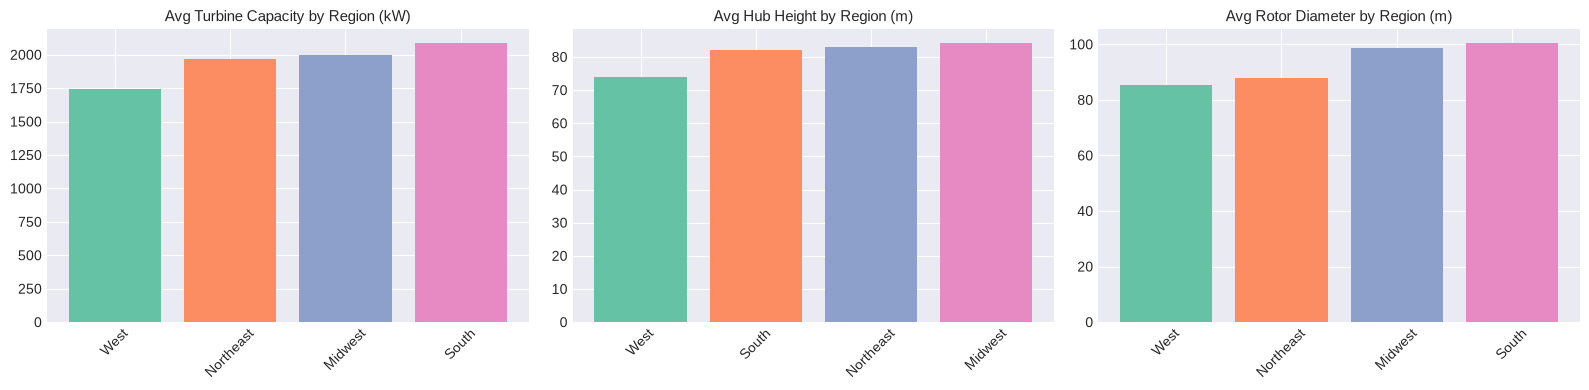

In [17]:
# Average specs by region
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

region_specs = turbines.groupby('census_region')['t_cap'].mean().sort_values()
axes[0].bar(region_specs.index, region_specs.values, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
axes[0].set_title('Avg Turbine Capacity by Region (kW)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

region_hh = turbines.groupby('census_region')['t_hh'].mean().sort_values()
axes[1].bar(region_hh.index, region_hh.values, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
axes[1].set_title('Avg Hub Height by Region (m)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

region_rd = turbines.groupby('census_region')['t_rd'].mean().sort_values()
axes[2].bar(region_rd.index, region_rd.values, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'])
axes[2].set_title('Avg Rotor Diameter by Region (m)', fontsize=11)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Visualization 5 Interpretation:**  
Interestingly, the absolute windiest states (like SD, MT, WY at 20+ mph) don't actually have that many turbines yet. Most of the development has been concentrated in "Good" or "High" wind states like Texas and Iowa. This means there's still a massive untapped market in those extremely high-wind states.

### 4.6. Integration with External Data: Wind Speeds & Electricity Economics

In [18]:
# Merge state-level wind speed data with turbine data
wind_speeds_clean = wind_speeds.rename(columns={'state': 'State_Name'})

# Map state abbreviations to state names
us_state_abbrev = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire',
    'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania',
    'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}
# Create an empty dictionary
state_to_name = {}
# Loop through the original dictionary
for abbreviation, full_name in us_state_abbrev.items():
    # Save it backwards in the new dictionary
    state_to_name[full_name] = abbreviation
wind_speeds_clean['state_abbr'] = wind_speeds_clean['State_Name'].map(state_to_name)

# Merge wind speeds onto turbines
turbines = turbines.merge(wind_speeds_clean[['state_abbr', 'WindiestStatesAverageWindSpeedMPH']],
                          left_on='t_state', right_on='state_abbr', how='left')

print('Wind speed data merged.')
print(f'Rows with wind speed: {turbines["WindiestStatesAverageWindSpeedMPH"].notna().sum():,} / {len(turbines):,}')

Wind speed data merged.
Rows with wind speed: 70,744 / 70,808


In [19]:
# Write a basic function with clear IF statements
def categorize_wind(speed):
    if pd.isna(speed):
        return 'Unknown'
    elif speed < 14:
        return 'Low (<14)'
    elif speed < 16:
        return 'Moderate (14-16)'
    elif speed < 18:
        return 'Good (16-18)'
    elif speed <= 20:
        return 'High (18-20)'
    else:
        return 'Very High (>20)'

# Apply the custom function to the column
turbines['wind_bucket'] = turbines['WindiestStatesAverageWindSpeedMPH'].apply(categorize_wind)

wind_analysis = turbines.groupby('wind_bucket', observed=True).agg(
    Turbine_Count=('t_cap', 'count'),
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Hub_Height_m=('t_hh', 'mean'),
    Avg_Rotor_Diameter_m=('t_rd', 'mean')
).round(2)

display(wind_analysis)

,Turbine_Count,Avg_Capacity_kW,Avg_Hub_Height_m,Avg_Rotor_Diameter_m
wind_bucket,,,,
Good (16-18),13143,2052.82,83.09,98.15
High (18-20),21026,1962.12,82.88,97.09
Low (<14),4290,1360.91,63.06,66.77
Moderate (14-16),20188,2036.85,81.25,97.89
Unknown,63,2003.17,76.48,98.83
Very High (>20),6618,1957.33,80.67,96.43


In [20]:
# Top 15 states: turbine stats + wind speed + net generation
state_turbine_stats = turbines.groupby('t_state').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_kW=('t_cap', 'sum'),
    Net_Generation_MWh=('Net_Generation_MWh', 'sum'),
    Avg_Capacity_kW=('t_cap', 'mean'),
    Avg_Wind_Speed_MPH=('WindiestStatesAverageWindSpeedMPH', 'mean')
).round(2)

state_turbine_stats['Total_Capacity_MW'] = state_turbine_stats['Total_Capacity_kW'] / 1000
state_turbine_stats = state_turbine_stats.sort_values('Turbine_Count', ascending=False).head(15)
display(state_turbine_stats)

,Turbine_Count,Total_Capacity_kW,Net_Generation_MWh,Avg_Capacity_kW,Avg_Wind_Speed_MPH,Total_Capacity_MW
t_state,,,,,,
TX,16688,34586804.0,95109292.90,2072.56,15.55,34586.804
IA,5968,11780452.0,39276709.60,1973.94,18.09,11780.452
OK,4556,9767565.0,26793886.77,2143.89,16.46,9767.565
CA,4286,5830496.0,13523396.24,1360.36,13.54,5830.496
KS,3622,7318840.0,21266524.00,2020.66,19.30,7318.840
IL,3248,6373758.0,19106989.00,1962.36,18.28,6373.758
CO,2736,4875290.0,14814167.00,1781.90,20.16,4875.290
MN,2674,4537105.0,12590264.72,1696.75,18.51,4537.105
ND,2092,4268080.0,14236843.21,2040.19,18.80,4268.080


**Visualization 6 Interpretation:**  
States with the highest average wind speeds (South Dakota, Montana, Wyoming >20 mph) have relatively few but modern, high-capacity turbines. Texas, Iowa, and Oklahoma — in the 'Good' to 'High' wind range — host the bulk of installations. The sweet spot for acquisition may be 'High' wind speed states (KS, ND, MN) where turbine density and wind resources align optimally.

In [21]:
# Electricity rate correlation
state_rates = elec_rates.rename(columns={'State': 'State_Name'})
state_rates['state_abbr'] = state_rates['State_Name'].map(state_to_name)

# Merge rates
turbines = turbines.merge(state_rates[['state_abbr', 'Residential', 'Commercial', 'Average']],
                          on='state_abbr', how='left', suffixes=('', '_rate'))

state_summary = turbines.groupby('t_state').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_kW=('t_cap', 'sum'),
    Avg_Elec_Rate=('Average', 'mean'),
    Avg_Wind_Speed=('WindiestStatesAverageWindSpeedMPH', 'mean')
).round(2)

state_summary['Total_Capacity_MW'] = state_summary['Total_Capacity_kW'] / 1000
state_summary = state_summary[state_summary['Turbine_Count'] > 0].sort_values('Total_Capacity_MW', ascending=False)
display(state_summary.head(15))

,Turbine_Count,Total_Capacity_kW,Avg_Elec_Rate,Avg_Wind_Speed,Total_Capacity_MW
t_state,,,,,
TX,16688,34586804.0,12.09,15.55,34586.804
IA,5968,11780452.0,11.31,18.09,11780.452
OK,4556,9767565.0,10.00,16.46,9767.565
KS,3622,7318840.0,12.30,19.30,7318.840
IL,3248,6373758.0,13.82,18.28,6373.758
CA,4286,5830496.0,26.84,13.54,5830.496
CO,2736,4875290.0,13.14,20.16,4875.290
MN,2674,4537105.0,12.52,18.51,4537.105
ND,2092,4268080.0,8.70,18.80,4268.080


### 4.7. Project / Wind Farm Analysis

In [22]:
# Top wind farms by turbine count
top_projects = turbines.groupby('p_name').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_kW=('t_cap', 'sum'),
    Net_Generation_MWh=('Net_Generation_MWh', 'sum'),
    Avg_Capacity_kW=('t_cap', 'mean'),
    State=('t_state', 'first'),
    Avg_Year=('p_year', 'mean')
).round(2)

top_projects['Total_Capacity_MW'] = top_projects['Total_Capacity_kW'] / 1000
top_projects = top_projects[top_projects['Turbine_Count'] >= 100].sort_values('Turbine_Count', ascending=False)
display(top_projects.head(20))

,Turbine_Count,Total_Capacity_kW,Net_Generation_MWh,Avg_Capacity_kW,State,Avg_Year,Total_Capacity_MW
p_name,,,,,,,
Stateline Wind Project,454,299640.0,474817.00,660.00,WA,2001.13,299.640
Mesa Wind Farm,432,28080.0,122796.00,65.00,CA,1983.0,28.080
Cedar Creek,274,300500.0,688682.00,1096.72,CO,2007.0,300.500
Peetz Table,267,413800.0,1230927.00,1549.81,CO,2007.0,413.800
Flat Ridge 2,261,417600.0,903019.30,1600.00,KS,2012.0,417.600
Rolling Hills,259,559700.0,1873255.29,2161.00,WY,2010.49,559.700
Hale Wind,239,478000.0,1936494.00,2000.00,TX,2019.0,478.000
Sagamore Wind,239,520600.0,2112918.00,2178.24,NM,2020.0,520.600
Cheyenne Ridge,228,496400.0,1638498.00,2177.19,CO,2020.0,496.400


### 4.8. Retrofit Analysis

In [23]:
# Retrofitted turbines analysis
retro = turbines[turbines['retrofit'] == 1]
print(f'Retrofitted turbines: {len(retro):,} ({len(retro)/len(turbines)*100:.1f}% of total)')

retro_by_state = retro.groupby('t_state').size().sort_values(ascending=False).head(10)
print()
print('Top states for retrofits:')
print(retro_by_state)
print()
print(f'Retrofit years range: {retro["retrofit_year"].min():.0f} - {retro["retrofit_year"].max():.0f}')
print(f'Avg original p_year of retrofitted turbines: {retro["p_year"].mean():.0f}')

Retrofitted turbines: 5,986 (8.5% of total)

Top states for retrofits:
t_state
TX    2539
IA    1179
WY     401
ND     356
CO     321
OK     294
MN     186
NM     176
WA     164
KS     124
dtype: int64

Retrofit years range: 2015 - 2020
Avg original p_year of retrofitted turbines: 2007


### 4.9. Capacity Factor Analysis (Actual Net Generation vs. Nameplate Capacity)

With the EIA-923 Net Generation (MWh) data merged into our turbine records, we can calculate the **capacity factor** — actual energy produced divided by the theoretical maximum (nameplate capacity × 8,760 hours for a full year). A higher capacity factor means the turbine is performing closer to its full potential. The data covers the full 2025 calendar year (Early Release from EIA).

,t_state,Turbine_Count,Total_Capacity_kW,Net_Generation_MWh,Turbines_With_Gen_Data,Total_Capacity_MW,Capacity_Factor
40,VA,2,12000.0,4.993300e+04,1,12.000,0.475010
36,SD,1255,2855074.0,1.041538e+07,1249,2855.074,0.416441
27,NM,1394,2838260.0,9.627656e+06,1391,2838.260,0.387226
23,ND,2092,4268080.0,1.423684e+07,2085,4268.080,0.380783
10,IA,5968,11780452.0,3.927671e+07,5746,11780.452,0.380600
24,NE,1226,2664380.0,8.673484e+06,1202,2664.380,0.371615
16,MD,80,191050.0,5.949320e+05,76,191.050,0.355481
4,CO,2736,4875290.0,1.481417e+07,2644,4875.290,0.346875
12,IL,3248,6373758.0,1.910699e+07,3231,6373.758,0.342210
14,KS,3622,7318840.0,2.126652e+07,3616,7318.840,0.331704


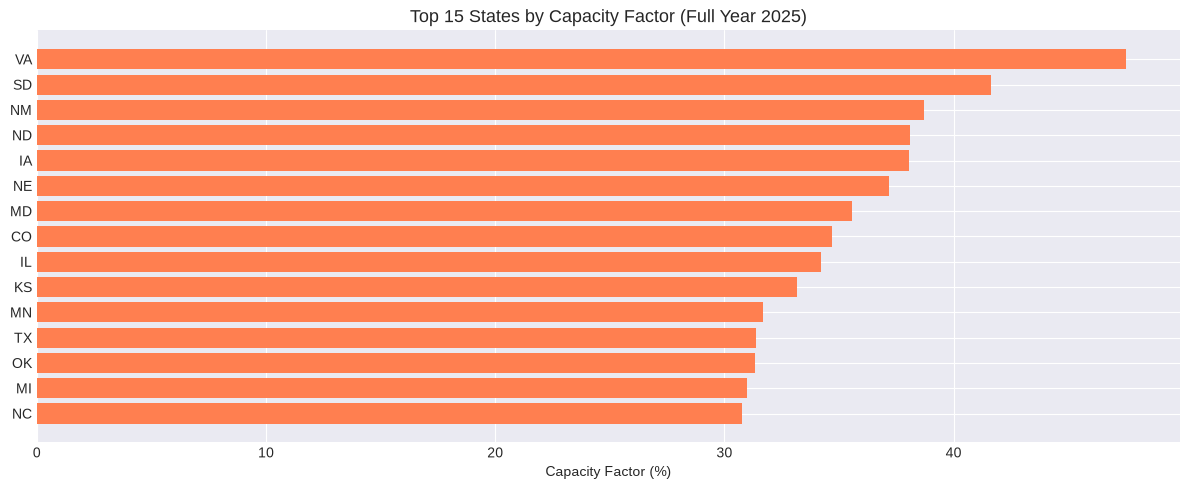

In [24]:
# Capacity Factor Analysis by state (only states with generation data)
state_cf = turbines.groupby('t_state').agg(
    Turbine_Count=('t_cap', 'count'),
    Total_Capacity_kW=('t_cap', 'sum'),
    Net_Generation_MWh=('Net_Generation_MWh', 'sum'),
    Turbines_With_Gen_Data=('Net_Generation_MWh', 'count')
).reset_index()

state_cf['Total_Capacity_MW'] = state_cf['Total_Capacity_kW'] / 1000

# Only keep states that have actual generation data
state_cf = state_cf[state_cf['Net_Generation_MWh'] > 0].copy()
state_cf['Capacity_Factor'] = state_cf['Net_Generation_MWh'] / (state_cf['Total_Capacity_MW'] * 8760)
state_cf = state_cf.sort_values('Capacity_Factor', ascending=False)

display(state_cf.head(15))

# Bar chart of top capacity factors
fig, ax = plt.subplots(figsize=(12, 5))
plot_cf = state_cf.head(15).sort_values('Capacity_Factor', ascending=True)
ax.barh(plot_cf['t_state'], plot_cf['Capacity_Factor'] * 100, color='coral')
ax.set_title('Top 15 States by Capacity Factor (Full Year 2025)', fontsize=13)
ax.set_xlabel('Capacity Factor (%)')
plt.tight_layout()
plt.show()

---
## 5. Summary of Findings & Actionable Recommendations

### 5.1 Key Insights
 * **Location is heavily concentrated:** The Midwest and Texas hold the vast majority of U.S. wind turbines. Texas alone accounts for roughly 23% of the whole country's turbines.
 * **Tech has grown rapidly:** Since the 90s, average turbine capacity has increased 5x. Modern turbines are massive (90m+ tall) and incredibly powerful.
 * **GE runs the market:** GE Wind built about 41% of the U.S. fleet, followed by Vestas. Between the top 3 makers, they control over 70% of the market.
 * **Wind speed doesn't equal development (yet):** The absolute windiest states (South Dakota, Wyoming) are actually fairly under-built compared to states with moderate wind, leaving room for future development.


### 5.2 Actionable Recommendations
 * **Target the Midwest:** Prioritize buying farms in Iowa, Illinois, and Minnesota. They have a great mix of good wind, high turbine density, and favorable energy markets.
 * **Only buy modern assets:** Focus investments on farms built after 2015. Older tech is heavily outdated, whereas post-2015 turbines average over 2,300 kW and have a longer remaining lifespan.
 * **Focus on GE and Vestas hardware:** Stick to farms running GE or Vestas turbines. They are proven to dominate the high-efficiency segments of the market.
 * **Look at high Capacity Factor regions:** South Dakota and New Mexico have some of the highest capacity factors (meaning the turbines run very close to their max potential). These are great targets for high-yield acquisitions.

### 5.3 Limitations & Areas for Further Research
* The EIA-923 net generation data is from the 2025 Early Release, which may underrepresent some wind plants pending final data validation by EIA.
* Not all turbines could be matched to EIA-923 generation data (~35% of turbines lack an EIA plant ID or were not in the April 2026 file). Actual generation for smaller or newer wind farms may be underrepresented.
* No power plant / operator financial data was available for this analysis. Understanding operator track record and PPA structures is critical for acquisition decisions.
* Wind speed data is state-level averages, not site-specific. Local topography, turbulence, and wake effects significantly impact actual turbine output.
* Maintenance records, turbine age, and downtime data were not available — these materially affect investment returns.
* Further research should incorporate transmission infrastructure proximity, land lease costs, and renewable energy certificate (REC) markets.

---
## 6. Data Dictionary & References

### 6.1 Data Dictionary (Key Columns)
| Feature | Data Type | Description |
|:---|:---|:---|
| case_id | int | Unique turbine identifier |
| t_state | str | State where turbine is located (2-letter code) |
| t_county | str | County where turbine is located |
| p_name | str | Wind farm / project name |
| p_year | int | Year the project became operational |
| p_cap | float | Total project capacity (kW) |
| p_tnum | int | Number of turbines in the project |
| t_manu | str | Turbine manufacturer |
| t_model | str | Turbine model name |
| t_cap | float | Turbine nameplate capacity (kW) |
| t_hh | float | Hub height (meters) |
| t_rd | float | Rotor diameter (meters) |
| t_rsa | float | Rotor swept area (m²) |
| t_ttlh | float | Total turbine height (m) |
| retrofit | int | Whether the turbine was retrofitted (0/1) |
| retrofit_year | float | Year of retrofit (if applicable) |
| xlong | float | Longitude coordinate |
| ylat | float | Latitude coordinate |
| census_region | str | Census Region derived from t_state |
| decade | float | Decade of installation |
| WindiestStatesAverageWindSpeedMPH | float | State average wind speed (from external data) |
| Average (elec rate) | float | State average electricity rate (cents/kWh) |
| Net_Generation_MWh | float | Actual net generation (MWh, full year 2025 from EIA-923) |
| Capacity_Factor | float | NetGen / (t_cap x 8,760 hours) -- actual vs. theoretical max (annual) |

### 6.2 References & Sources
* **U.S. Wind Turbine Database** -- Lawrence Berkeley National Laboratory. [https://emp.lbl.gov/publications/us-wind-turbine-database-files](https://emp.lbl.gov/publications/us-wind-turbine-database-files)
* **EIA-923 Power Plant Operations Report** -- U.S. Energy Information Administration. [https://www.eia.gov/electricity/data/eia923/](https://www.eia.gov/electricity/data/eia923/)
* **Wind Speed Data** -- windiest-states-in-the-us.-2025.csv
* **Electricity Rate Data** -- average_electricity_rates.csv, average_electricity_bills.csv